# Unemployment Analysis with Python

This notebook analyzes the unemployment rate in India, focusing on the sharp increase during the Covid-19 pandemic. We will explore the dataset to understand the impact across different regions and time periods.

## 1. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set visual style
sns.set(style="whitegrid")

## 2. Load the Dataset

In [17]:
# Loading the dataset
df = pd.read_csv('../TASK-2 DATASET/Unemployment_Rate_upto_11_2020.csv')

# Display first few rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Data Cleaning and Preprocessing

In [18]:
# Check for missing values
print(df.isnull().sum())

# Inspect column names
print(df.columns)

# Cleaning column names (removing leading/trailing spaces)
df.columns = df.columns.str.strip()

# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Renaming columns for easier access
df.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate', 
                   'Estimated Employed': 'Employed', 
                   'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'}, inplace=True)

df.head()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


## 4. Exploratory Data Analysis (EDA)

In [19]:
# Summary statistics
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


### Unemployment Rate by Region

C:\Users\PRACHIGARG\AppData\Local\Temp\ipykernel_36920\3648219411.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




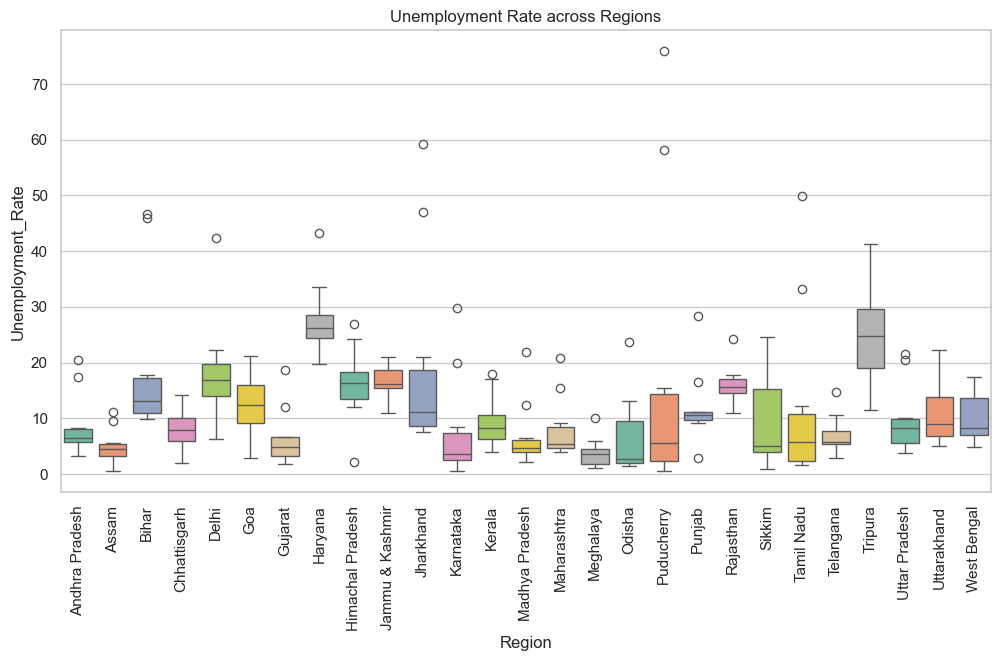

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Unemployment_Rate', data=df, palette='Set2')
plt.xticks(rotation=90)
plt.title('Unemployment Rate across Regions')
plt.show()

### Trend of Unemployment Rate Over Time

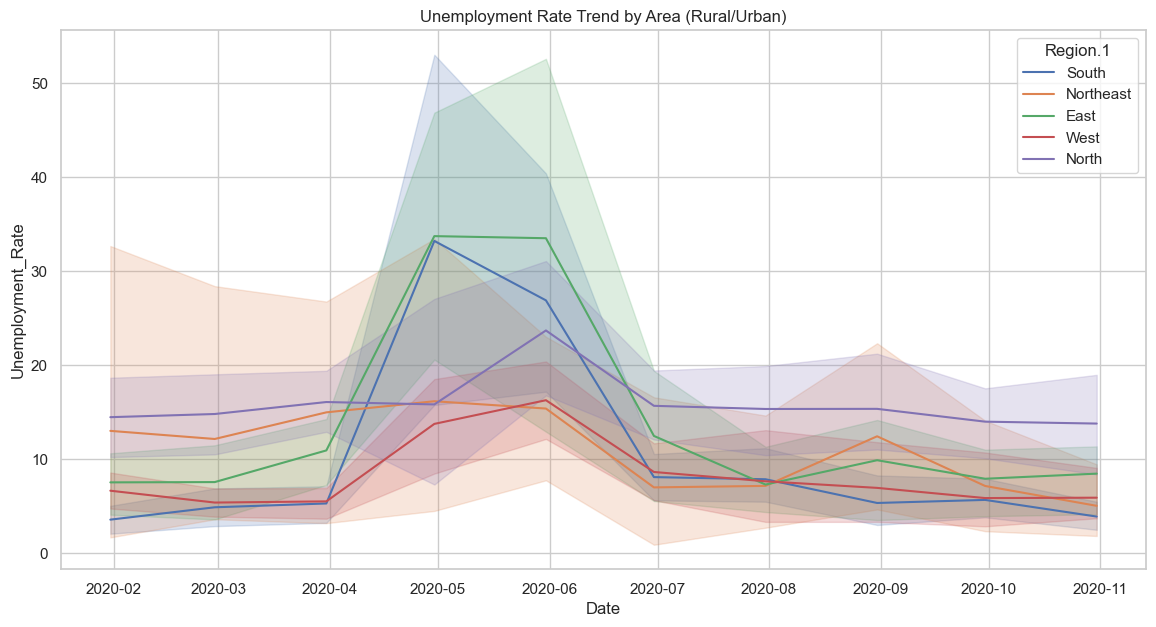

In [21]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Unemployment_Rate', hue='Region.1', data=df)
plt.title('Unemployment Rate Trend by Area (Rural/Urban)')
plt.show()

### Average Unemployment Rate by Region

C:\Users\PRACHIGARG\AppData\Local\Temp\ipykernel_36920\2820209066.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




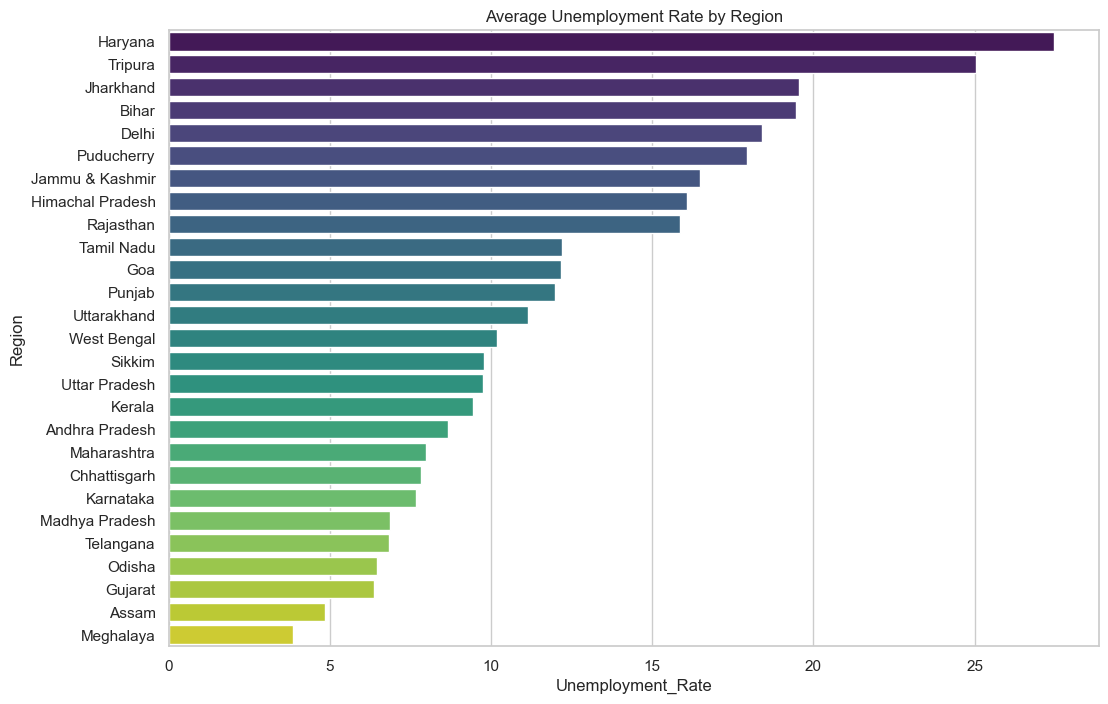

In [22]:
region_wise = df.groupby('Region')['Unemployment_Rate'].mean().reset_index().sort_values(by='Unemployment_Rate', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Unemployment_Rate', y='Region', data=region_wise, palette='viridis')
plt.title('Average Unemployment Rate by Region')
plt.show()

### Correlation Heatmap

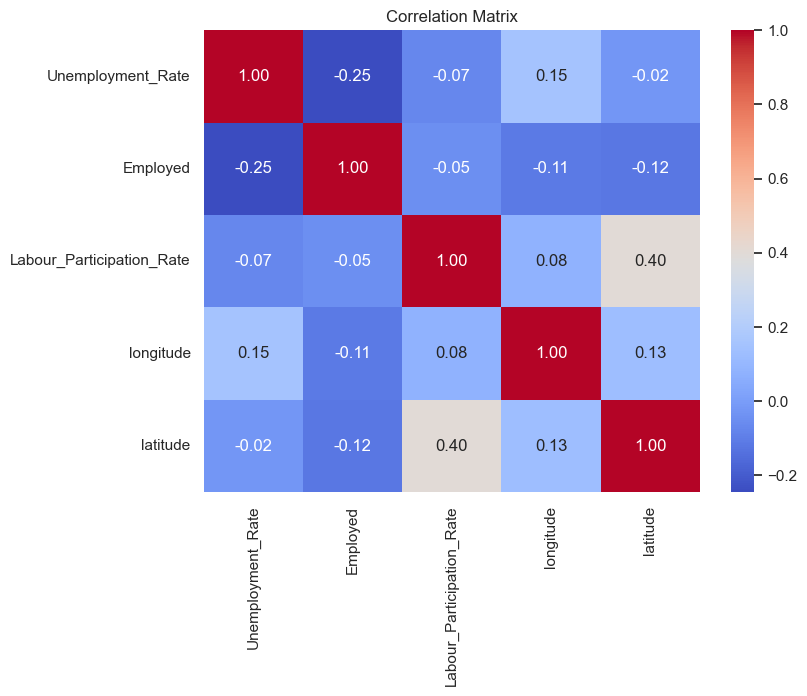

In [23]:
plt.figure(figsize=(8, 6))
# Using numeric_only=True to avoid ValueError with string columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Sunburst Plot of Unemployment Rate

In [24]:
unemploment = df[["Region", "Region.1", "Unemployment_Rate"]]
figure = px.sunburst(unemploment, path=["Region.1", "Region"], 
                     values="Unemployment_Rate", 
                     width=700, height=700, color_continuous_scale="RdY1Gn", 
                     title="Unemployment Rate in India")
figure.show()

## 5. Conclusion

The analysis reveals a significant variation in the unemployment rate across different regions in India. Certain states experienced much higher rates during the lockdowns in 2020. The trend analysis clearly indicates the peak periods of unemployment that coincide with the pandemic waves.